**Purpose: To Predict Whether a Spotify User Will Churn or Remain Active.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
data = pd.read_csv("C:/Users/PC/Documents/Projects/Python Project/spotify_churn_dataset.csv");

# Basic info
df = pd.DataFrame(data)
df.info()
df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


**Check For Duplicates & Missing Values**

In [3]:
# Check duplicates and missing values
df.duplicated().sum()
df.isnull().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

**Numerical Columns Summary**

In [44]:
# Numerical Columns Summary

num_cols = ['age','listening_time','songs_played_per_day','offline_listening']
print("\nNumerical Columns Summary:\n", df[num_cols].describe())


Numerical Columns Summary:
                age  listening_time  songs_played_per_day  offline_listening
count  8000.000000     8000.000000           8000.000000        8000.000000
mean     37.662125      154.068250             50.127250           0.747750
std      12.740359       84.015596             28.449762           0.434331
min      16.000000       10.000000              1.000000           0.000000
25%      26.000000       81.000000             25.000000           0.000000
50%      38.000000      154.000000             50.000000           1.000000
75%      49.000000      227.000000             75.000000           1.000000
max      59.000000      299.000000             99.000000           1.000000


**Check How Many Users are Active vs Churned**

In [4]:
# Churn Analysis
churn_counts = df["is_churned"].value_counts()
print(churn_counts)

churn_percentage = df["is_churned"].value_counts(normalize = True) * 100
print(churn_percentage)

is_churned
0    5929
1    2071
Name: count, dtype: int64
is_churned
0    74.1125
1    25.8875
Name: proportion, dtype: float64


**Churn Analysis**

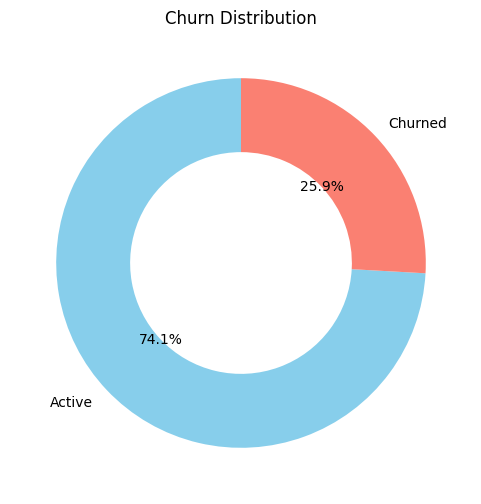

In [45]:
# Churn distribution
churn_counts = df["is_churned"].value_counts()

# Donut chart
plt.figure(figsize=(6,6))
plt.pie(churn_counts, 
        labels=["Active", "Churned"], 
        autopct="%1.1f%%", 
        startangle=90, 
        colors=['skyblue','salmon'], 
        wedgeprops=dict(width=0.4))  # donut effect

plt.title("Churn Distribution")
plt.show()


**Subscription Type Distribution**


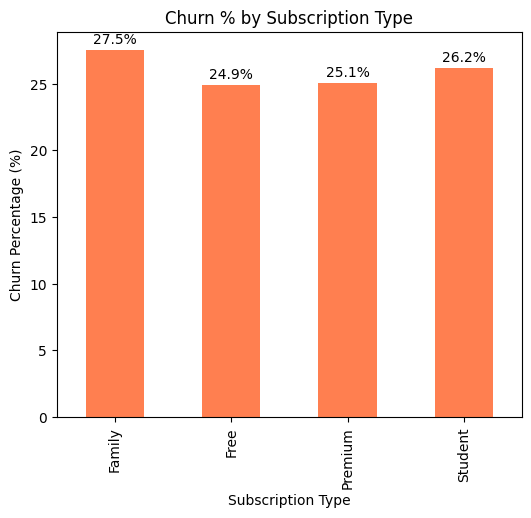

In [40]:
# Subscription type analysis
churn_by_sub = df.groupby('subscription_type')['is_churned'].mean() * 100

ax = churn_by_sub.plot(kind='bar', color='coral', figsize=(6,5))

plt.title("Churn % by Subscription Type")
plt.ylabel("Churn Percentage (%)")
plt.xlabel("Subscription Type")

# Add values on top of each bar
for i, v in enumerate(churn_by_sub):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()


**Age Distribution**

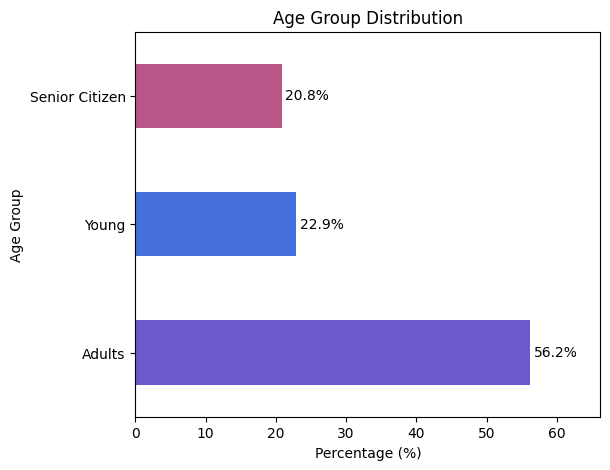

In [93]:
# Age group anlysis
df.loc[(df["age"] <= 25), "customer_group"] = "Young"
df.loc[(df["age"] >= 26) & (df["age"] <= 50), "customer_group"] = "Adults"
df.loc[(df["age"] >= 51 ), "customer_group"] = "Senior Citizen"

age_groups = df['customer_group'].value_counts(normalize=True) * 100  # convert to %
plt.figure(figsize=(6,5))
ax = age_groups.plot(kind='barh', color=['#6A5ACD','#4570DB','#BA5588'])
plt.xlim(0, age_groups.max() + 10)  # add padding to right side

plt.title('Age Group Distribution')
plt.xlabel('Percentage (%)')
plt.ylabel('Age Group')

# Add percentage values on bars
for i, v in enumerate(age_groups):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.show()


**Listening Behavior**

In [21]:
# Compare Numerical Features by Churn

active = df[df["is_churned"]==0]
churned = df[df["is_churned"]==1]

print("\nAverage Listening Time (Active):", active['listening_time'].mean())
print("Average Listening Time (Churned):", churned['listening_time'].mean())


Average Listening Time (Active): 154.4467869792545
Average Listening Time (Churned): 152.9845485272815


**Gender Distribution**

gender
Male      33.6375
Female    33.2375
Other     33.1250
Name: proportion, dtype: float64


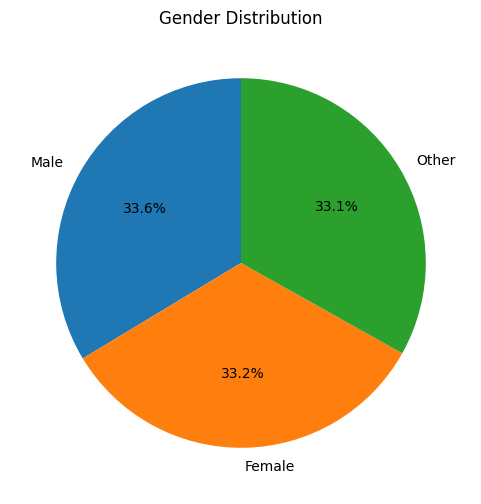

In [46]:
# Gender
df["gender"].value_counts()
gender_percentage = df["gender"].value_counts(normalize = True) * 100
print(gender_percentage)

# Pie chart: Gender distribution
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

**Device Type**

device_type
Desktop    34.7250
Web        32.7875
Mobile     32.4875
Name: proportion, dtype: float64


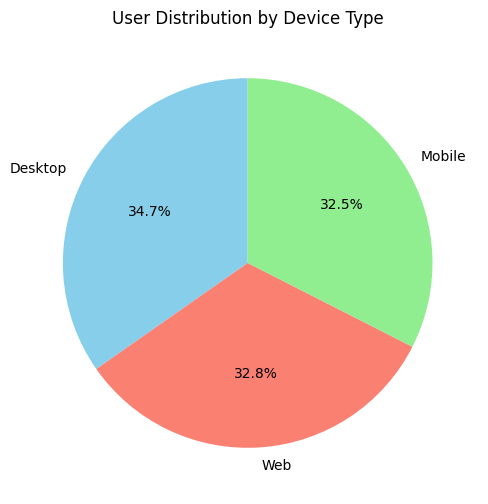

In [55]:

# Device type
df["device_type"].value_counts()
device_type_percentage = df["device_type"].value_counts(normalize = True) * 100
print(device_type_percentage)


device_type_percentage = df["device_type"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
colors = ['skyblue','salmon','lightgreen']

# Pie chart with labels + percentages
plt.pie(device_type_percentage, 
        labels=device_type_percentage.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colors,
        textprops={'color':'black'})

plt.title("User Distribution by Device Type")
plt.show()


**Dashboard**

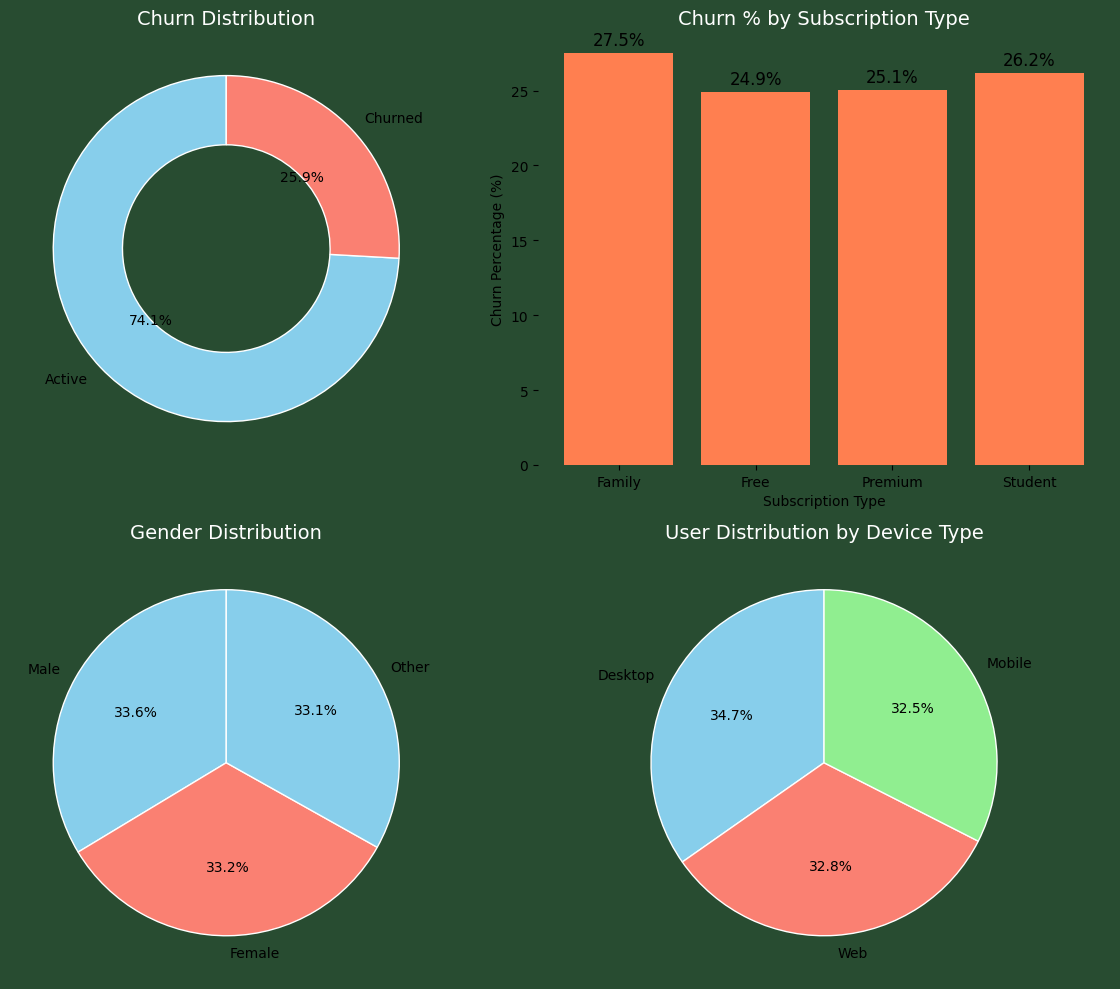

In [88]:
# Dashboard
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Set figure background
fig.patch.set_facecolor('#284C31')


# Remove white border (spines) from bar chart only
for spine in axs[0,1].spines.values():
    spine.set_visible(False)


# ------------------ 1. Donut Chart (Churn Distribution) ------------------
churn_counts = df["is_churned"].value_counts()
axs[0,0].pie(churn_counts, labels=["Active", "Churned"], autopct="%1.1f%%", startangle=90,  
             colors=['skyblue','salmon'], wedgeprops=dict(width=0.4, edgecolor='white'))
axs[0,0].set_title("Churn Distribution", color='white', fontsize=14)

# ------------------ 2. Bar Chart (Subscription Type) ------------------
bars = axs[0,1].bar(churn_by_sub.index, churn_by_sub.values, color='coral', edgecolor='none')
axs[0,1].set_facecolor('none')  # transparent background
axs[0,1].set_title("Churn % by Subscription Type", color='white', fontsize=14)
axs[0,1].set_ylabel("Churn Percentage (%)")
axs[0,1].set_xlabel("Subscription Type")


# Add values on top of bars in white
for i, v in enumerate(churn_by_sub):
    axs[0,1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=12)

# ------------------ 3. Pie Chart (Gender) ------------------
gender_counts = df['gender'].value_counts()
axs[1,0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90, 
             colors=['skyblue','salmon'], wedgeprops=dict(edgecolor='white'))
axs[1,0].set_title("Gender Distribution", color='white', fontsize=14)

# ------------------ 4. Pie Chart (Device Type) ------------------
axs[1,1].pie(device_type_percentage, 
             labels=device_type_percentage.index, 
             autopct='%1.1f%%', 
             startangle=90,
             colors=['skyblue','salmon','lightgreen'],
             wedgeprops=dict(edgecolor='white'))
axs[1,1].set_title("User Distribution by Device Type", color='white', fontsize=14)


plt.tight_layout()
plt.show()


#  Key Insights

- **Churn Rate** – 25.9% of users churned, while 74.1% remained active.  
  This indicates 1 in 4 users cancel their subscription, showing a moderate churn risk.

- **Subscription Type Impact** – Family users show the highest churn risk 27.5%,  
  while Free 24.9%, Premium 25.1%, and Student 26.2% are almost similar.  
  Subscription type impacts churn but not drastically.

- **Age Group Distribution** – Adults (26–50 yrs) are the largest user segment (56.2%),  
  followed by Young (22.9%) and Senior Citizens (20.8%).  
  Spotify’s core audience is adults.

- **Gender Distribution** – Almost evenly distributed among Male (33.6%), Female (33.2%), and Other (33.1%),  
  suggesting churn is not strongly influenced by gender.

- **Device Preference** – Desktop users dominate slightly (34.7%),  
  while Web (32.8%) and Mobile (32.5%) are close, indicating multi-device engagement is common.

---

# Final Conclusion

To reduce churn and increase engagement, Spotify should focus on:

- The churn rate is significant (1 in 4 users), and subscription type has more influence than demographics or device usage.
- Since listening time doesn’t differ much between active and churned users, content quality, engagement features, or pricing strategy might be bigger churn drivers than pure usage.
- Retention strategies should focus on subscription-specific engagement, particularly Free and Family plans,  
  to reduce churn while keeping Premium users loyal.
